<a href="https://colab.research.google.com/github/francji1/01NAEX/blob/main/code/01NAEX_Ex01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01NAEX - Exercise 01: Simple comparative experiments

Data and exercises come from D. C. Montgomery: *Design and Analysis of Experiments*, 8th edition, Chapter 2.
Problem numbers follow the 8th edition.

## Learning goals

* Compare two treatments with the two-sample $t$-test (pooled and Welch) and interpret the $p$-value and the confidence interval.
* Test the equality of two variances with the $F$-test.
* Check the normality assumption (kernel density estimate, normal probability plot, Shapiro-Wilk test).
* Compute the power of a test and the sample size needed to reach a given power.


## Setup

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, t, f, shapiro
from statsmodels.stats.power import TTestIndPower

## Example from the lecture: Portland cement mortar

Lecture 1 compared the tension bond strength of a modified and an unmodified mortar formulation
(Montgomery, Example 2.1). We repeat the analysis in Python: $F$-test for the variances, two-sample $t$-tests,
confidence intervals, normality checks, and the power of the test.

In [59]:
# Data arrays
y1 = np.array([16.85,16.40,17.21,16.35,16.52,17.04,16.96,17.15,16.59,16.57])  # Modified Mortar
y2 = np.array([16.62,16.75,17.37,17.12,16.98,16.87,17.34,17.02,17.08,17.27])  # Unmodified Mortar

# Sample variances
s1_squared = np.var(y1, ddof=1)
s2_squared = np.var(y2, ddof=1)

# Degrees of freedom
dfn = len(y1) - 1  # Degrees of freedom numerator
dfd = len(y2) - 1  # Degrees of freedom denominator

# F-test statistic
F = s1_squared / s2_squared

# Two-tailed p-value
p_value = 2 * min(f.cdf(F, dfn, dfd), 1 - f.cdf(F, dfn, dfd))

print('F-statistic:', F)
print('Degrees of freedom:', dfn, 'and', dfd)
print('p-value:', p_value)

F-statistic: 1.6292573577265188
Degrees of freedom: 9 and 9
p-value: 0.4784603394194413


In [60]:
# 1. Two-sample t-test assuming equal variances (pooled; var.equal = TRUE in R)
t_stat_equal_var, p_value_equal_var = stats.ttest_ind(y1, y2, equal_var=True)

# Calculate confidence interval for equal variance
n1, n2 = len(y1), len(y2)
mean_diff = np.mean(y1) - np.mean(y2)
pooled_std = np.sqrt(((n1 - 1) * np.var(y1, ddof=1) + (n2 - 1) * np.var(y2, ddof=1)) / (n1 + n2 - 2))
se_pooled = pooled_std * np.sqrt(1/n1 + 1/n2)
conf_interval_equal_var = stats.t.interval(0.95, df=n1 + n2 - 2, loc=mean_diff, scale=se_pooled)

# 2. Welch's t-test (var.equal = FALSE in R)
t_stat_unequal_var, p_value_unequal_var = stats.ttest_ind(y1, y2, equal_var=False)
df_unequal_var = ((np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)**2) / \
                 ((np.var(y1, ddof=1)/n1)**2/(n1-1) + (np.var(y2, ddof=1)/n2)**2/(n2-1))

# Calculate confidence interval for unequal variance
se_unequal = np.sqrt(np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)
conf_interval_unequal_var = stats.t.interval(0.95, df=df_unequal_var, loc=mean_diff, scale=se_unequal)

# Results for t-test assuming equal variances
print("Two-Sample T-Test Assuming Equal Variances")
print(f"t-statistic: {t_stat_equal_var}")
print(f"p-value: {p_value_equal_var}")
print(f"95% confidence interval: {conf_interval_equal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")
print()

# Results for Welch's t-test (unequal variances)
print("Welch's Two-Sample T-Test (Assuming Unequal Variances)")
print(f"t-statistic: {t_stat_unequal_var}")
print(f"p-value: {p_value_unequal_var}")
print(f"Degrees of freedom: {df_unequal_var}")
print(f"95% confidence interval: {conf_interval_unequal_var}")
print(f"Mean of y1: {np.mean(y1)}, Mean of y2: {np.mean(y2)}")


Two-Sample T-Test Assuming Equal Variances
t-statistic: -2.1868757949582633
p-value: 0.042196715924889903
95% confidence interval: (np.float64(-0.5450733877678522), np.float64(-0.010926612232152355))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005

Welch's Two-Sample T-Test (Assuming Unequal Variances)
t-statistic: -2.1868757949582633
p-value: 0.04299838008890299
Degrees of freedom: 17.02484516235282
95% confidence interval: (np.float64(-0.5461741394750395), np.float64(-0.00982586052496498))
Mean of y1: 16.764000000000003, Mean of y2: 17.042000000000005


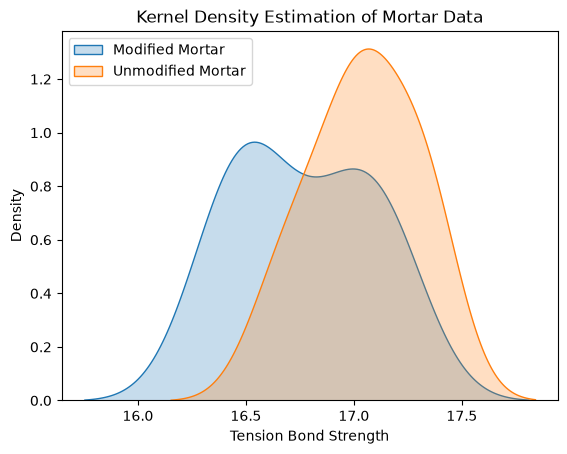

In [61]:
# Kernel Density Plot
sns.kdeplot(y1, fill=True, label='Modified Mortar')
sns.kdeplot(y2, fill=True, label='Unmodified Mortar')
plt.title('Kernel Density Estimation of Mortar Data')
plt.xlabel('Tension Bond Strength')
plt.legend()
plt.show()

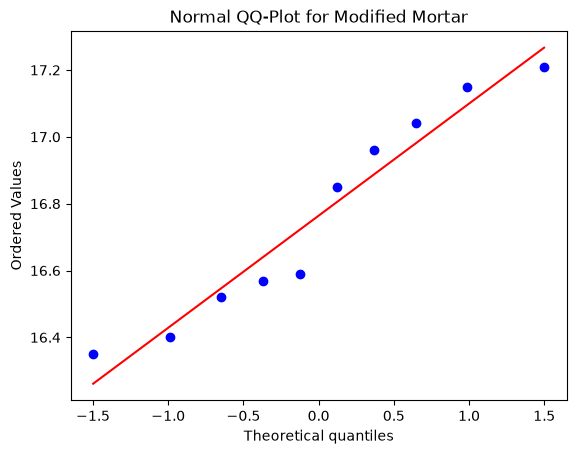

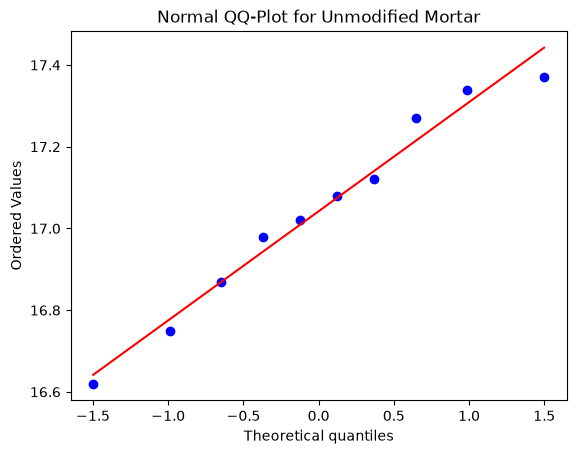

In [62]:
# QQ-Plot for y1
plt.figure()
stats.probplot(y1, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Modified Mortar')
plt.show()

# QQ-Plot for y2
plt.figure()
stats.probplot(y2, dist="norm", plot=plt)
plt.title('Normal QQ-Plot for Unmodified Mortar')
plt.show()

In [63]:
# Shapiro-Wilk test for y1
statistic_y1, p_value_y1 = shapiro(y1)
print(f'Shapiro-Wilk Test for y1: Statistic={statistic_y1}, p-value={p_value_y1}')

# Shapiro-Wilk test for y2
statistic_y2, p_value_y2 = shapiro(y2)
print(f'Shapiro-Wilk Test for y2: Statistic={statistic_y2}, p-value={p_value_y2}')

Shapiro-Wilk Test for y1: Statistic=0.9186332804164983, p-value=0.34569686488904733
Shapiro-Wilk Test for y2: Statistic=0.962619287409993, p-value=0.8152773091281766


In [64]:
# Parameters
effect_size = (np.mean(y1) - np.mean(y2)) / np.sqrt((s1_squared + s2_squared) / 2)
alpha = 0.05
power = 0.95

# Create an instance of the power analysis class
analysis = TTestIndPower()

# Calculate required sample size
sample_size = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
print(f'Required sample size per group: {np.ceil(sample_size)}')

# Calculate power of the test with n=10
actual_power = analysis.power(effect_size=effect_size, nobs1=10, alpha=alpha, alternative='two-sided')
print(f'Power of the test with n=10 per group: {actual_power}')

Required sample size per group: 29.0
Power of the test with n=10 per group: 0.5436442278126237


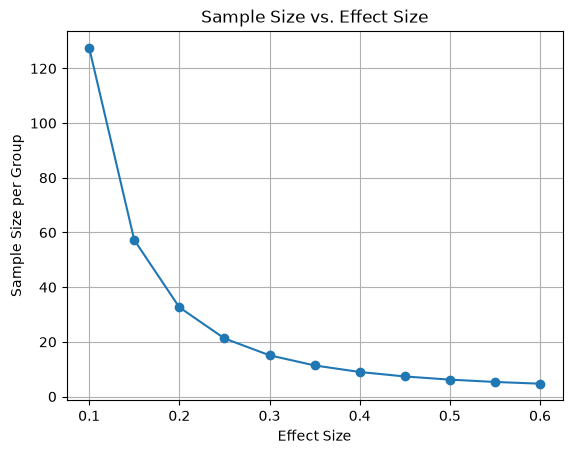

In [65]:
# Parameters
alpha = 0.05
power = 0.80
sd = 0.284  # Standard deviation
effect_sizes = np.array([0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6])

# Calculate sample sizes
analysis = TTestIndPower()
sample_sizes = []
for delta in effect_sizes:
    effect_size = delta / sd
    n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')
    sample_sizes.append(n)

# Plotting
plt.plot(effect_sizes, sample_sizes, marker='o')
plt.xlabel('Effect Size')
plt.ylabel('Sample Size per Group')
plt.title('Sample Size vs. Effect Size')
plt.grid(True)
plt.show()


## Assignment

* Run the notebook above and get familiar with Python.
* Solve the following problems from Montgomery, *Design and Analysis of Experiments* (8th edition). Start in class and finish at home.
* Submit your solved notebook as a pull request into the `HW/` folder of the course repository, named
  `HW/01NAEX_Ex01_HW_<Surname>.ipynb` (see `HW/README.md`).
  **Deadline: Sunday 4 October 2026** (the next lecture is on 5 October; 28 September is a public holiday).

### Exercise 2.20

The shelf life of a carbonated beverage is of interest. Ten bottles are randomly selected and tested,
and the following results (in days) are obtained:

| | | | | |
|---|---|---|---|---|
| 108 | 124 | 124 | 106 | 115 |
| 138 | 163 | 159 | 134 | 139 |

* We would like to demonstrate that the mean shelf life exceeds 120 days. Set up appropriate hypotheses for investigating this claim.
* Test these hypotheses using significance level $\alpha = 0.01$. Find the P-value for the test. What are your conclusions?
* Construct a 99 percent confidence interval on the mean shelf life.
* Can shelf life be adequately described or modeled by a normal distribution? What effect would a violation of this assumption have on the test procedure you used in solving the previous questions?

In [66]:
# Read the data from the URL
url_20 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_20.csv"
df20 = pd.read_csv(url_20, sep=";")

# Display the first few rows of the dataframe
df20.head()


,Days
0,108
1,124
2,124
3,106
4,115


**Solution:**

In [67]:
# H0: μ <= 120 vs. H1: μ > 120

# T-test
y = df20["Days"]
n = len(y)
y_mean = np.mean(y)
S = np.std(y, ddof=1) / np.sqrt(n)

alpha = 0.01
confidence = 1-alpha
conf_interval = stats.t.interval(confidence, n-1, loc=y_mean, scale=S)

t_stat, p_value = stats.ttest_1samp(y, 120, alternative="greater")

print("T-Test Assuming Equal Variances")
print(f"t-statistic: {t_stat}")
print(f"p-value: {p_value}")
print(f"95% confidence interval: {conf_interval}")
print(f"Mean of y: {y_mean}")
print(f"H0 rejected on alpha={alpha}: {True if p_value < alpha else False}")


T-Test Assuming Equal Variances
t-statistic: 1.7797582046490772
p-value: 0.05440887347507948
95% confidence interval: (np.float64(110.91401817160775), np.float64(151.08598182839225))
Mean of y: 131.0
H0 rejected on alpha=0.01: False


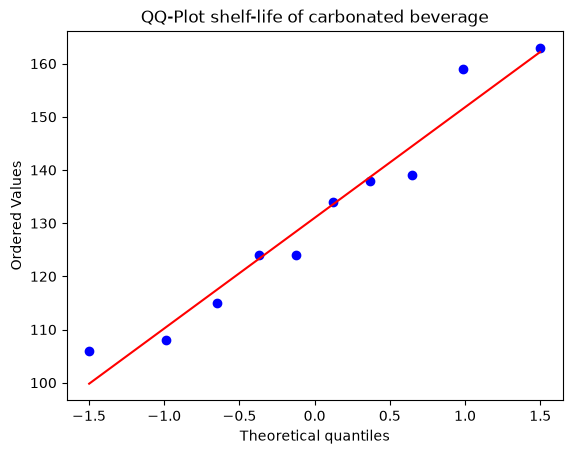

Shapiro statistics: 0.9365414967428929
P-value: 0.515209542483786
H0 (samples follow normal distribution) rejected on alpha=0.05: False


In [68]:
# Normality testing
plt.figure()
stats.probplot(y, dist="norm", plot=plt)
plt.title("QQ-Plot shelf-life of carbonated beverage")
plt.show()

alpha = 0.05
shapiro_stats, shapiro_p_value = shapiro(y)
print(f"Shapiro statistics: {shapiro_stats}")
print(f"P-value: {shapiro_p_value}")
print(f"H0 (samples follow normal distribution) rejected on alpha={alpha}: {True if shapiro_p_value < alpha else False}")

Shelf life may be modeled by normal distribution (but assuming only based on 10 samples, which is generally not enough). If this factor wasn't normally distributed, assumption on T-test is breached and T statistics may not follow Student distribution.

### Exercise 2.21

In semiconductor manufacturing, wet chemical etching is often used to remove silicon from the backs of wafers prior to metallization. The **etch rate** is an important characteristic of this process. Two different etching solutions are being evaluated. Eight randomly selected wafers have been etched in each solution and the observed etch rates (in mils/min) are shown below:

| Solution 1 | Solution 2 |
|------------|------------|
|  9.9       | 10.2       |
|  9.4       | 10.0       |
| 10.0       | 10.7       |
| 10.3       | 10.5       |
| 10.6       | 10.6       |
| 10.3       | 10.2       |
|  9.3       | 10.4       |
|  9.8       | 10.3       |

**(a)** Do the data indicate that the claim that both solutions have the same mean etch rate is valid? Use α = 0.05 and assume equal variances.  

**(b)** Find a 95% confidence interval on the difference in mean etch rates.  

**(c)** Use normal probability plots to investigate the adequacy of the assumptions of normality and equal variances.  

**(d)** Compute the power of the test in part (a). Assume that the true difference in means and the common variance equal the estimates obtained from the data. How many observations per group would be required to achieve power greater than 0.9 to detect a difference of Δ = 0.3 at significance level α = 0.05?


In [69]:
# Read the data from the URL
url_21 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_21.csv"
df21 = pd.read_csv(url_21, sep=";")

# Display the first few rows of the dataframe
df21.head()

,Solution1,Solution2
0,9.9,10.2
1,9.4,10.0
2,10.0,10.7
3,10.3,10.5
4,10.6,10.6


**Solution:**

In [70]:
y1, y2 = df21["Solution1"], df21["Solution2"]
n1, n2 = len(y1), len(y2)

alpha = 0.05
confidence = 1-alpha

# T-test assuming equal variances
ttest_stats_equal_var, ttest_p_value_equal_var = stats.ttest_ind(y1, y2, equal_var=True)

# Confidence interval
mean_shift_equal_var = np.mean(y1) - np.mean(y2)
s_pooled_equal_var = ((n1-1)*np.var(y1, ddof=1) + (n2-1)*np.var(y2, ddof=1)) / (n1+n2-2)
s_equal_var = np.sqrt(s_pooled_equal_var)*np.sqrt(1/n1 + 1/n2)
ttest_interval_equal_var = stats.t.interval(confidence, df=n1+n2-2, loc=mean_shift_equal_var, scale=s_equal_var)

print("T-Test Assuming Equal Variances")
print(f"T-test statistics: {ttest_stats_equal_var}")
print(f"P-value: {ttest_p_value_equal_var}")
print(f"95% confidence interval: {ttest_interval_equal_var}")
print(f"Mean difference (y1 - y2): {mean_shift_equal_var:.4f}")
print(f"H0 rejected on alpha={alpha}: {True if ttest_p_value_equal_var < alpha else False}")


# T-test assuming different variances
ttest_stats_ineq_var, ttest_p_value_ineq_var = stats.ttest_ind(y1, y2, equal_var=False)

# Confidence interval
s1 = np.var(y1, ddof=1)
s2 = np.var(y2, ddof=1)
s_ineq_var = np.sqrt(s1/n1 + s2/n2)
df_ineq_var = ((np.var(y1, ddof=1)/n1 + np.var(y2, ddof=1)/n2)**2) / \
                 ((np.var(y1, ddof=1)/n1)**2/(n1-1) + (np.var(y2, ddof=1)/n2)**2/(n2-1))
ttest_interval_ineq_var = stats.t.interval(confidence, df=df_ineq_var, loc=mean_shift_equal_var, scale=s_ineq_var)

print("\n\nT-Test Assuming Inequal Variances")
print(f"T-test statistics: {ttest_stats_ineq_var}")
print(f"P-value: {ttest_p_value_ineq_var}")
print(f"95% confidence interval: {ttest_interval_ineq_var}")
print(f"Mean difference (y1 - y2): {mean_shift_equal_var:.4f}")
print(f"H0 rejected on alpha={alpha}: {True if ttest_p_value_ineq_var < alpha else False}")


T-Test Assuming Equal Variances
T-test statistics: -2.3016143834229035
P-value: 0.03723610772585904
95% confidence interval: (np.float64(-0.7968930221926924), np.float64(-0.028106977807310363))
Mean difference (y1 - y2): -0.4125
H0 rejected on alpha=0.05: True


T-Test Assuming Inequal Variances
T-test statistics: -2.3016143834229035
P-value: 0.0429978866588502
95% confidence interval: (np.float64(-0.8093362974301082), np.float64(-0.015663702569894744))
Mean difference (y1 - y2): -0.4125
H0 rejected on alpha=0.05: True


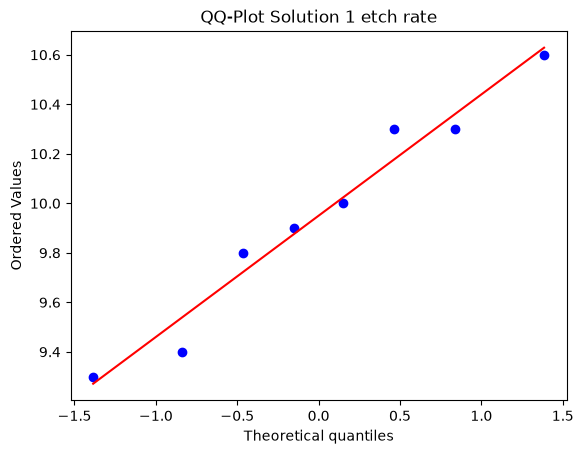

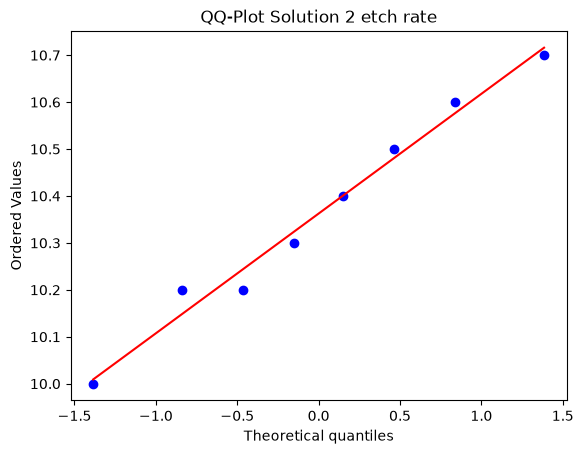

In [71]:
# Normality testing

# Solution1
plt.figure()
stats.probplot(y1, dist="norm", plot=plt)
plt.title("QQ-Plot Solution 1 etch rate")
plt.show()

# Solution2
plt.figure()
stats.probplot(y2, dist="norm", plot=plt)
plt.title("QQ-Plot Solution 2 etch rate")
plt.show()

In [72]:
alpha = 0.05

# Solution1
shapiro_stats_y1, shapiro_p_value_y1 = shapiro(y1)
print(f"Shapiro statistics: {shapiro_stats_y1}")
print(f"P-value: {shapiro_p_value_y1}")
print(f"H0 (samples follow normal distribution) rejected on alpha={alpha}: {True if shapiro_p_value_y1 < alpha else False}")

# Solution2
shapiro_stats_y2, shapiro_p_value_y2 = shapiro(y2)
print(f"Shapiro statistics: {shapiro_stats_y2}")
print(f"P-value: {shapiro_p_value_y2}")
print(f"H0 (samples follow normal distribution) rejected on alpha={alpha}: {True if shapiro_p_value_y2 < alpha else False}")

Shapiro statistics: 0.9548980729741825
P-value: 0.7603428524493492
H0 (samples follow normal distribution) rejected on alpha=0.05: False
Shapiro statistics: 0.9767975416408974
P-value: 0.9453603577017222
H0 (samples follow normal distribution) rejected on alpha=0.05: False


In [73]:
analysis = TTestIndPower()
sd = np.sqrt(s_pooled_equal_var)

# Power of the test in (a) with observed difference and pooled std
effect_size = abs(mean_shift_equal_var) / sd
actual_power = analysis.power(effect_size=effect_size, nobs1=n1, alpha=alpha, alternative="two-sided")
print(f"Pooled std: {sd}")
print(f"Power of the test with n={n1} per group: {actual_power}")

# Sample size for difference 0.3 with power 0.9
sample_size = analysis.solve_power(effect_size=0.3 / sd, alpha=alpha, power=0.9, alternative="two-sided")
print(f"Required sample size per group for difference 0.3: {np.ceil(sample_size)}")


Pooled std: 0.35844405819756975
Power of the test with n=8 per group: 0.5723756003991541
Required sample size per group for difference 0.3: 31.0


1) Pooled t-test: H0 is rejected – the mean etch rates of the two solutions differ (Welch's test gives the same conclusion).

2) QQ-plots and Shapiro tests show no significant departure from normality.

3) Power of the test in (a) is \sim 0.57. To detect a difference of 0.3 with power 0.9, 31 observations per group are required.


### Exercise 2.26

The following are the burning times (in minutes) of chemical flares of two different formulations. The design engineers are interested in both the mean and
variance of the burning times.

|Type1|   | Type2 | |
|----|----|----|----|
| 65 | 82 | 64 | 56 |
| 81 | 67 | 71 | 69 |
| 57 | 59 | 83 | 74 |
| 66 | 75 | 59 | 82 |
| 82 | 70 | 65 | 79 |


1. Test the hypothesis that the two variances are equal. Use $\alpha = 0.05$.
2. Using the results of part 1), test the hypothesis that the mean burning
times are equal. Use $\alpha = 0.05$. What is the P-value for this test?
3. Discuss the role of the normality assumption in this problem. Check the
assumption of normality for both types of flares
4. If the mean burning times of the two flares differ by as much as 2 minutes, find the power of the test. What sample size would be required to detect an actual difference in mean burning time of 1 minute with a power of at least 0.9?

In [74]:
# Read the data from the URL
url_26 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_26.csv"
df26 = pd.read_csv(url_26, sep=";")

# Display the first few rows of the dataframe
df26.head()

,Type1,Type2
0,65,64
1,81,71
2,57,83
3,66,59
4,82,65


**Solution:**

In [75]:
# H0: σ1^2 = σ2^2 vs. H1: σ1^2 != σ2^2
y1, y2 = df26["Type1"], df26["Type2"]
n1, n2 = len(y1), len(y2)

alpha = 0.05

s1 = np.var(y1, ddof=1)
s2 = np.var(y2, ddof=1)
F_stat = s1 / s2
F_p_value = 2 * min(f.cdf(F_stat, n1-1, n2-1), 1 - f.cdf(F_stat, n1-1, n2-1))

print("F-Test for Equality of Variances")
print(f"Variances: {s1}, {s2}")
print(f"F-statistic: {F_stat}")
print(f"P-value: {F_p_value}")
print(f"H0 rejected on alpha={alpha}: {True if F_p_value < alpha else False}")


F-Test for Equality of Variances
Variances: 85.82222222222222, 87.73333333333332
F-statistic: 0.9782168186423507
P-value: 0.9743664928217833
H0 rejected on alpha=0.05: False


In [76]:
# H0: μ1 = μ2 vs. H1: μ1 != μ2
confidence = 1-alpha

ttest_stats, ttest_p_value = stats.ttest_ind(y1, y2, equal_var=True)

# Confidence interval
mean_shift = np.mean(y1) - np.mean(y2)
s_pooled = ((n1-1)*s1 + (n2-1)*s2) / (n1+n2-2)
s_equal_var = np.sqrt(s_pooled)*np.sqrt(1/n1 + 1/n2)
ttest_interval = stats.t.interval(confidence, df=n1+n2-2, loc=mean_shift, scale=s_equal_var)

print("T-Test Assuming Equal Variances")
print(f"T-test statistics: {ttest_stats}")
print(f"P-value: {ttest_p_value}")
print(f"95% confidence interval: {ttest_interval}")
print(f"Mean difference (y1 - y2): {mean_shift:.4f}")
print(f"H0 rejected on alpha={alpha}: {True if ttest_p_value < alpha else False}")


T-Test Assuming Equal Variances
T-test statistics: 0.04800768184369234
P-value: 0.9622387844779036
95% confidence interval: (np.float64(-8.552441107577055), np.float64(8.95244110757706))
Mean difference (y1 - y2): 0.2000
H0 rejected on alpha=0.05: False


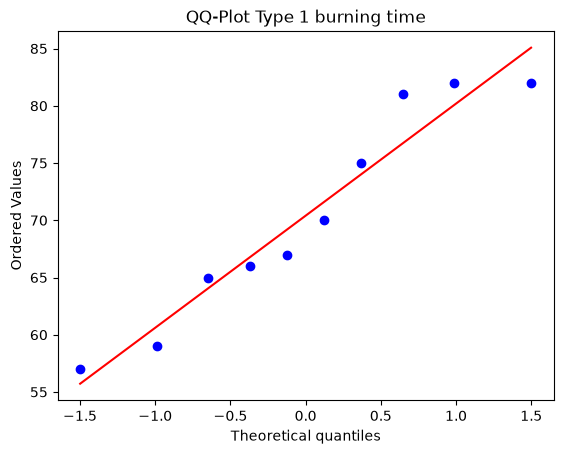

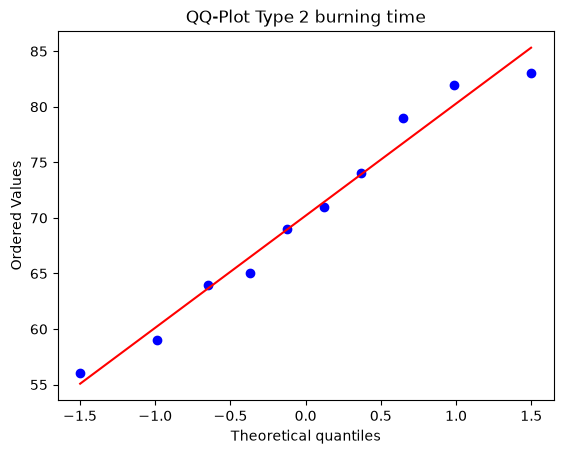

In [77]:
# Normality testing

# Type1
plt.figure()
stats.probplot(y1, dist="norm", plot=plt)
plt.title("QQ-Plot Type 1 burning time")
plt.show()

# Type2
plt.figure()
stats.probplot(y2, dist="norm", plot=plt)
plt.title("QQ-Plot Type 2 burning time")
plt.show()


In [78]:
# Type1
shapiro_stats_y1, shapiro_p_value_y1 = shapiro(y1)
print(f"Shapiro statistics: {shapiro_stats_y1}")
print(f"P-value: {shapiro_p_value_y1}")
print(f"H0 (samples follow normal distribution) rejected on alpha={alpha}: {True if shapiro_p_value_y1 < alpha else False}")

# Type2
shapiro_stats_y2, shapiro_p_value_y2 = shapiro(y2)
print(f"Shapiro statistics: {shapiro_stats_y2}")
print(f"P-value: {shapiro_p_value_y2}")
print(f"H0 (samples follow normal distribution) rejected on alpha={alpha}: {True if shapiro_p_value_y2 < alpha else False}")


Shapiro statistics: 0.9135859502818687
P-value: 0.30654202782643913
H0 (samples follow normal distribution) rejected on alpha=0.05: False
Shapiro statistics: 0.954780069563549
P-value: 0.7251095082628229
H0 (samples follow normal distribution) rejected on alpha=0.05: False


In [79]:
analysis = TTestIndPower()
sd = np.sqrt(s_pooled)

# Power of the test for difference of 2 minutes
effect_size_2 = 2 / sd
power_2 = analysis.power(effect_size=effect_size_2, nobs1=n1, alpha=alpha, alternative="two-sided")
print(f"Pooled std: {sd}")
print(f"Power of the test for difference 2 min (n={n1}): {power_2}")

# Sample size for difference of 1 minute with power 0.9
effect_size_1 = 1 / sd
sample_size = analysis.solve_power(effect_size=effect_size_1, alpha=alpha, power=0.9, alternative="two-sided")
print(f"Required sample size per group for difference 1 min: {np.ceil(sample_size)}")


Pooled std: 9.31545907498808
Power of the test for difference 2 min (n=10): 0.0740326987702983
Required sample size per group for difference 1 min: 1825.0


1) F-test does not reject equality of variances, so we can assume equal variances.

2) Pooled t-test: H0 is not rejected – there is no statisticla evidence that the mean burning times differ.

3) Both the F-test and the t-test assume normally distributed data; the F-test is in fact very sensitive to violations of normality, while the t-test is more robust. QQ-plots and Shapiro tests show no significant departure from normality for either type.

4) The standard deviation is large compared with a difference of 2 min, so the power of the test is very low. Detecting a difference of 1 min with power 0.9 would require ~1800 observations per group.


### Exercise 2.30

Front housings for cell phones are manufactured in an injection molding process. The time the part is allowed to cool in the mold before removal is thought to influence the occurrence of a particularly troublesome cosmetic defect, flow lines, in the finished housing. After manufacturing, the housings are inspected visually and assigned a score between 1 and 10 based on their appearance, with 10 corresponding to a perfect part and 1 corresponding to a completely defective part. An experiment was conducted using two cool-down times, 10 and 20 seconds, and 20 housings were evaluated at each level of cool-down time. All 40 observations in this experiment were run in random order.

Cool-down time 10 seconds:

| | | | |
|---|---|---|---|
| 1 | 3 | 2 | 6 |
| 1 | 5 | 3 | 3 |
| 5 | 2 | 1 | 1 |
| 5 | 6 | 2 | 8 |
| 3 | 2 | 5 | 3 |

Cool-down time 20 seconds:

| | | | |
|---|---|---|---|
| 7 | 6 | 8 | 9 |
| 5 | 5 | 9 | 7 |
| 5 | 4 | 8 | 6 |
| 6 | 8 | 4 | 5 |
| 6 | 8 | 7 | 7 |

* Is there evidence to support the claim that the longer cool-down time results in fewer appearance defects? Use $\alpha = 0.05$.
* What is the P-value for the test conducted in the previous part?
* Find a 95 percent confidence interval on the difference in means. Provide a practical interpretation of this interval.
* Compute the power of the test.

In [80]:
# Read the data from the URL
url_30 = "https://raw.githubusercontent.com/francji1/01NAEX/main/data/Ex02_30.csv"
df30 = pd.read_csv(url_30, sep=";")

# Display the first few rows of the dataframe
df30.head()

,10 seconds,20 seconds
0,1,7
1,2,8
2,1,5
3,3,9
4,5,5


**Solution:**

In [81]:
# H0: σ10^2 = σ20^2 vs. H1: σ10^2 != σ20^2
y10, y20 = df30["10 seconds"], df30["20 seconds"]
n10, n20 = len(y10), len(y20)

alpha = 0.05

s10 = np.var(y10, ddof=1)
s20 = np.var(y20, ddof=1)
F_stat = s10 / s20
F_p_value = 2 * min(f.cdf(F_stat, n10-1, n20-1), 1 - f.cdf(F_stat, n10-1, n20-1))

print("F-Test for Equality of Variances")
print(f"Variances: {s10}, {s20}")
print(f"F-statistic: {F_stat}")
print(f"P-value: {F_p_value}")
print(f"H0 rejected on alpha={alpha}: {True if F_p_value < alpha else False}")


F-Test for Equality of Variances
Variances: 4.028947368421054, 2.3684210526315788
F-statistic: 1.701111111111112
P-value: 0.2558534624070936
H0 rejected on alpha=0.05: False


In [82]:
# H0: μ20 <= μ10 vs. H1: μ20 > μ10 (higher score = fewer defects)
ttest_stats, ttest_p_value = stats.ttest_ind(y20, y10, equal_var=True, alternative="greater")

print("One-Sided T-Test Assuming Equal Variances")
print(f"T-test statistics: {ttest_stats}")
print(f"P-value: {ttest_p_value}")
print(f"Means: {np.mean(y10)}, {np.mean(y20)}")
print(f"H0 rejected on alpha={alpha}: {True if ttest_p_value < alpha else False}")


One-Sided T-Test Assuming Equal Variances
T-test statistics: 5.56961108764575
P-value: 1.1083364175492159e-06
Means: 3.35, 6.5
H0 rejected on alpha=0.05: True


In [83]:
confidence = 1-alpha

# Confidence interval (two-sided) for μ20 - μ10
mean_shift = np.mean(y20) - np.mean(y10)
s_pooled = ((n10-1)*s10 + (n20-1)*s20) / (n10+n20-2)
s_equal_var = np.sqrt(s_pooled)*np.sqrt(1/n10 + 1/n20)
ttest_interval = stats.t.interval(confidence, df=n10+n20-2, loc=mean_shift, scale=s_equal_var)

print(f"Mean difference (y20 - y10): {mean_shift:.4f}")
print(f"95% confidence interval: {ttest_interval}")


Mean difference (y20 - y10): 3.1500
95% confidence interval: (np.float64(2.0050651892970563), np.float64(4.2949348107029435))


In [84]:
analysis = TTestIndPower()
sd = np.sqrt(s_pooled)

# Power of the test with observed difference and pooled std
effect_size = mean_shift / sd
actual_power = analysis.power(effect_size=effect_size, nobs1=n10, alpha=alpha, alternative="larger")
print(f"Pooled std: {sd}")
print(f"Effect size: {effect_size}")
print(f"Power of the test with n={n10} per group: {actual_power}")


Pooled std: 1.7884865698479027
Effect size: 1.7612656718288267
Power of the test with n=20 per group: 0.999933954671495


1) F-test does not reject equality of variances, so the pooled t-test is used.

2) The one-sided t-test: H0 is rejected - there is strong evidence that the longer cool-down time results in fewer appearance defects.

3) 95% CI for μ20 - μ10. Practical interpretation: extending the cool-down time from 10 to 20 seconds increases the mean appearance score.

4) With the observed difference and pooled standard deviation and n = 20 per group, the power of the test is practically 1 - such a difference is detected almost surely.
